# Что нам дали: путеводитель по данным

Задача 8 «Международного хакатона 2026», АО «Москоллектор».

Тетрадь отвечает на вопрос «что лежит в выгрузке и как это читать». Она ничего
не моделирует. Кластеризация и признаки лежат в `01-eda-clustering.ipynb`.

Читать стоит целиком один раз перед тем, как трогать данные руками. Дальше
возвращаться к разделу 6: там собраны ловушки, на которых мы уже спотыкались.

| Раздел | О чём |
|---|---|
| 1 | Четыре файла и их колонки |
| 2 | Дерево объектов |
| 3 | Каналы датчиков и что означает каждый тип |
| 4 | Журнал значений: объём и его перекос |
| 5 | Такт опроса и природа значений |
| 6 | На что смотреть при ручном анализе |
| 7 | Как хранить это, чтобы модель можно было дообучать |

In [1]:
import os

os.environ["NUMBA_NUM_THREADS"] = "1"

import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATASET = ROOT / "raw_task" / "dataset"
PARQUET = ROOT / "eda" / "out" / "events.parquet"

BG, PANEL, LINE, TEXT, DIM = "#161C22", "#1D242B", "#2E3841", "#E4E9ED", "#9AA8B4"
RISK = ["#3E8C74", "#C89230", "#D4602F", "#C43B36"]
ACCENT = ["#6f8fb5", "#c96a3a", "#a884c0", "#4a7fb5", "#5f9ea0"]

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": PANEL, "savefig.facecolor": BG,
    "text.color": TEXT, "axes.labelcolor": DIM, "axes.edgecolor": LINE,
    "xtick.color": DIM, "ytick.color": DIM, "grid.color": LINE,
    "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 9, "figure.dpi": 110,
    "legend.facecolor": PANEL, "legend.edgecolor": LINE, "legend.labelcolor": DIM,
})

SI = FuncFormatter(lambda x, _: f"{x/1e6:.0f} млн" if x >= 1e6
                   else f"{x/1e3:.0f} тыс" if x >= 1e3 else f"{x:.0f}")

con = duckdb.connect()
con.execute("PRAGMA threads=8")
con.execute(f"CREATE VIEW ev AS SELECT * FROM '{PARQUET.as_posix()}'")
con.execute(f"""CREATE VIEW ch AS SELECT * FROM read_csv_auto(
    '{(DATASET / 'справочник_каналов_датчиков.csv').as_posix()}', header=true)""")
con.execute(f"""CREATE VIEW ob AS SELECT * FROM read_csv_auto(
    '{(DATASET / 'справочник_объектов_диспетчер.csv').as_posix()}', header=true)""")
print("готово")

готово


## 1. Четыре файла

Выгрузка лежит в `raw_task/dataset/`. В репозиторий она не входит: 15,9 ГБ.

In [2]:
files = []
for p in sorted(DATASET.iterdir()):
    files.append({"файл": p.name, "МБ": round(p.stat().st_size / 1e6, 1)})
files = pd.DataFrame(files)
files["доля"] = (files["МБ"] / files["МБ"].sum()).map("{:.1%}".format)
display(files)
print(f'итого {files["МБ"].sum()/1000:.1f} ГБ')

,файл,МБ,доля
0,ext-journal-2019.csv,1185.6,7.4%
1,ext-journal-2020.csv,1576.6,9.9%
2,ext-journal-2021.csv,2735.7,17.2%
3,ext-journal-2022.csv,2161.8,13.6%
4,ext-journal-2023.csv,1630.6,10.2%
5,ext-journal-2024.csv,2419.4,15.2%
6,ext-journal-2025.csv,2710.3,17.0%
7,ext-journal-2026.csv,1497.5,9.4%
8,журнал_событий_пример.csv,9.7,0.1%
9,справочник_каналов_датчиков.csv,1.3,0.0%


итого 15.9 ГБ


### Колонки

Историческая выгрузка и потоковый образец описывают одно и то же, но по-разному.
Загрузчик обязан читать оба формата.

In [3]:
hist = con.sql(f"""DESCRIBE SELECT * FROM read_csv_auto(
    '{(DATASET / 'ext-journal-2024.csv').as_posix()}', header=true) LIMIT 1""").df()
stream = con.sql(f"""DESCRIBE SELECT * FROM read_csv_auto(
    '{(DATASET / 'журнал_событий_пример.csv').as_posix()}', header=true) LIMIT 1""").df()

print("исторический журнал (ext-journal-*.csv)")
display(hist[["column_name", "column_type"]])
print("потоковый образец (журнал_событий_пример.csv)")
display(stream[["column_name", "column_type"]])

исторический журнал (ext-journal-*.csv)


,column_name,column_type
0,ид_события,BIGINT
1,ид_канала_данных,BIGINT
2,дата,DATE
3,время,TIME
4,тревожное,BOOLEAN
5,значение_датчика,VARCHAR


потоковый образец (журнал_событий_пример.csv)


,column_name,column_type
0,ид_события,BIGINT
1,ид_канала_данных,BIGINT
2,дата,DATE
3,время,TIME
4,тревожное,BOOLEAN
5,значение_датчика,VARCHAR


Различий три, и все три ломают наивный загрузчик.

1. Колонка значения называется `значение` в истории и `значение_датчика` в потоке.
2. Флаг тревоги в истории приходит как `f` и `t`, в потоке как `false` и `true`.
3. Поток берёт поля в кавычки, история нет.

Ещё одна ловушка не видна в схеме: файл `ext-journal-2025.csv` склеен из двух
выгрузок, и на строке 26 140 585 заголовок повторяется. Дублей на стыке нет, но
разбор без фильтра по `TRY_CAST(ид_события AS BIGINT) IS NOT NULL` даст битую
строку.

### Справочники

In [4]:
print("справочник каналов датчиков")
display(con.sql("DESCRIBE SELECT * FROM ch LIMIT 1").df()[["column_name", "column_type"]])
display(con.sql("SELECT * FROM ch LIMIT 3").df())

print("справочник объектов диспетчера")
display(con.sql("DESCRIBE SELECT * FROM ob LIMIT 1").df()[["column_name", "column_type"]])
display(con.sql("SELECT * FROM ob ORDER BY иерархия_уровень LIMIT 4").df())

справочник каналов датчиков


,column_name,column_type
0,ид_канала_данных,BIGINT
1,тип_инж_системы,VARCHAR
2,тип_датчика,VARCHAR
3,тег_инженерной_системы,VARCHAR
4,название_датчика,VARCHAR
5,ид_объект,BIGINT


,ид_канала_данных,тип_инж_системы,тип_датчика,тег_инженерной_системы,название_датчика,ид_объект
0,120578,Охранная подсистема,КД АВ,15-11.1.131.2.,КД АВ ПК28,20
1,120504,Пожарная охрана,Тепловой датчик,15-11.1.104.2.,ТД ПК86-85,20
2,120298,Температурная подсистема,Датчик температуры,15-11.1.4.1.,"Темп. ВШ ПК88,5",20


справочник объектов диспетчера


,column_name,column_type
0,ид_объект,BIGINT
1,иерархия_уровень,BIGINT
2,родитель,BIGINT
3,вид_объекта,VARCHAR
4,диспетчерское_название_объекта,VARCHAR


,ид_объект,иерархия_уровень,родитель,вид_объекта,диспетчерское_название_объекта
0,5773,1,3831,district,Район по эксплуатации
1,5,2,5773,controlHouse,объект Альфа
2,7,2,5773,controlHouse,объект Гамма
3,6,2,5773,controlHouse,объект Бета


Про колонку `тег_инженерной_системы` отдельно. Выглядит она осмысленно, вида
`15-11.1.131.2.`, и мы потратили на её разбор три дня. Заказчик на QA-сессии
объяснил: это тег протокола MQ, шины между инженерными системами. Его оставили
при обезличивании по ошибке вместо идентификатора объекта. **Колонка избыточна,
читать её не надо.** Связь даёт `ид_объект`.

## 2. Дерево объектов

Три уровня. Названия обезличены греческими буквами.

In [5]:
levels = con.sql("""
SELECT иерархия_уровень AS уровень, вид_объекта AS вид, count(*) AS узлов
FROM ob GROUP BY 1, 2 ORDER BY 1, 2
""").df()
display(levels)

print("район -> комплекс -> объект -> канал")
print("  1 район, 16 комплексов, 78 объектов,",
      con.sql("SELECT count(*) FROM ch").fetchone()[0], "каналов")
print("\nвсе каналы связаны с объектом:",
      con.sql("SELECT count(*) FROM ch WHERE ид_объект IS NULL").fetchone()[0] == 0)

,уровень,вид,узлов
0,1,district,1
1,2,controlHouse,16
2,3,controlHouse,49
3,3,guardObject,29


район -> комплекс -> объект -> канал
  1 район, 16 комплексов, 78 объектов, 11485 каналов

все каналы связаны с объектом: True


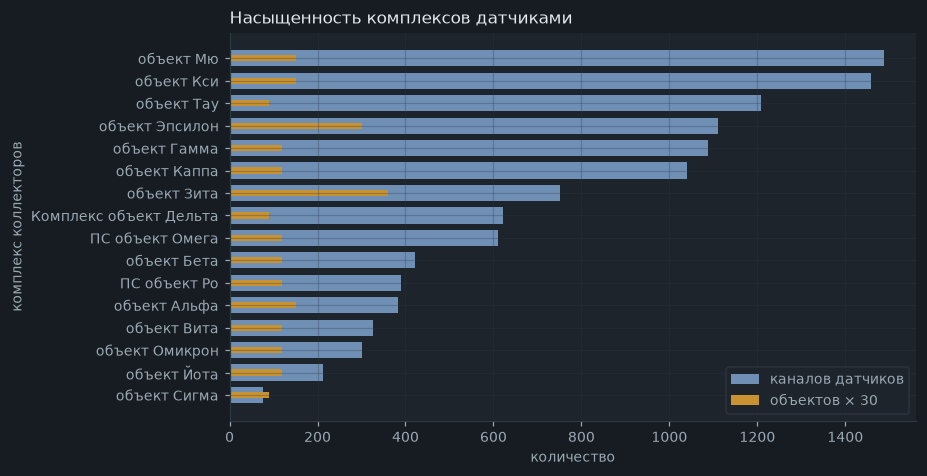

на объект приходится каналов: медиана 108 | разброс от 25 до 403


In [6]:
by_complex = con.sql("""
SELECT p.диспетчерское_название_объекта AS комплекс,
       count(DISTINCT o.ид_объект) AS объектов,
       count(c.ид_канала_данных)   AS каналов
FROM ob o JOIN ob p ON o.родитель = p.ид_объект
LEFT JOIN ch c ON c.ид_объект = o.ид_объект
WHERE o.иерархия_уровень = 3
GROUP BY 1 ORDER BY каналов DESC
""").df()

fig, ax = plt.subplots(figsize=(8.5, 4.4))
y = np.arange(len(by_complex))[::-1]
ax.barh(y, by_complex.каналов, color=ACCENT[0], height=0.72, label="каналов датчиков")
ax.barh(y, by_complex.объектов * 30, color=RISK[1], height=0.28, label="объектов × 30")
ax.set_yticks(y, by_complex.комплекс)
ax.set_xlabel("количество")
ax.set_ylabel("комплекс коллекторов")
ax.set_title("Насыщенность комплексов датчиками", loc="left", color=TEXT, fontsize=11)
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

print("на объект приходится каналов: медиана",
      int((by_complex.каналов / by_complex.объектов).median()),
      "| разброс от", int((by_complex.каналов / by_complex.объектов).min()),
      "до", int((by_complex.каналов / by_complex.объектов).max()))

Комплексы устроены очень по-разному. В `Мю` почти 1 500 каналов на пять
объектов, в `Сигме` 75 на три. Это значит, что усреднять по сети нельзя: любой
показатель «в среднем по комплексу» будет говорить в основном про `Мю` и `Кси`.

## 3. Типы датчиков и что они означают

Девятнадцать типов в шести инженерных системах. Ниже расшифровка: что это за
устройство и что оно пишет в журнал.

Расшифровка собрана из словаря значений самого журнала и из терминов ТЗ §1.
Там, где мы выводим смысл, а не читаем его из документа, стоит пометка.

In [7]:
GLOSSARY = {
    "Датчик дыма":          ("дымовой извещатель", "Обнаружен дым / Дыма нет", "ТЗ §1"),
    "Состояние фазы":       ("контроль фаз питающей линии", "Включен / Обесточен", "вывод"),
    "КД Дверь":             ("контактный датчик двери", "Не замкнут / Норма", "ТЗ §1"),
    "Датчик движения":      ("объёмный извещатель", "Обнаружено движение / Движения нет", "ТЗ §1"),
    "Переключатель":        ("режим шлейфа: взят или снят", "Включен / Выключен", "вывод"),
    "Состояние УИР-Р":      ("переговорное устройство связи с диспетчером",
                             "Рычаг сдернут / Вызов / Разговор", "вывод по словарю"),
    "Датчик температуры":   ("термодатчик", "число, °C", "ТЗ §1"),
    "Газовый датчик":       ("анализатор газовоздушной среды", "число, концентрация", "ТЗ §1"),
    "Тепловой датчик":      ("пороговый тепловой извещатель", "Не замкнут / Норма", "ТЗ §1"),
    "КД АВ":                ("контактный датчик аварийного выхода", "Не замкнут / Норма", "вывод"),
    "Состояние вентилятора": ("привод вентиляции", "Включен / Выключен / Обесточен", "ТЗ §13"),
    "Состояние насоса":     ("привод водооткачки", "Включен / Затоплен / Работают все насосы в АНС", "ТЗ §13"),
    "Ручной извещатель":    ("ручной пожарный извещатель", "Рычаг сдернут", "ТЗ §1"),
    "ИБП":                  ("источник бесперебойного питания", "заряд и Питание от батарей", "вывод"),
    "КД Люк":               ("контактный датчик люка", "Не замкнут / Норма", "ТЗ §13"),
    "Состояние охраны":     ("режим охраны зоны", "На охране / Снято с охраны", "вывод"),
    "Стекло":               ("датчик разбития стекла", "Не замкнут / Норма", "ТЗ §1"),
    "Датчик затопления":    ("датчик уровня воды", "Не замкнут / Норма", "ТЗ §1"),
    "9-секционный люк":     ("секционный люк", "Норма / Не замкнут", "вывод"),
}

types = con.sql("""
SELECT ch.тип_датчика AS тип, any_value(ch.тип_инж_системы) AS система,
       count(DISTINCT ch.ид_канала_данных) AS каналов,
       count(*) AS записей
FROM ev e JOIN ch ON ch.ид_канала_данных = e.channel_id
GROUP BY 1 ORDER BY каналов DESC
""").df()
types["что это"] = types.тип.map(lambda t: GLOSSARY.get(t, ("?", "", ""))[0])
types["что пишет"] = types.тип.map(lambda t: GLOSSARY.get(t, ("", "?", ""))[1])
types["источник"] = types.тип.map(lambda t: GLOSSARY.get(t, ("", "", "?"))[2])
display(types[["тип", "система", "что это", "что пишет", "каналов", "записей", "источник"]])

,тип,система,что это,что пишет,каналов,записей,источник
0,Датчик дыма,Пожарная охрана,дымовой извещатель,Обнаружен дым / Дыма нет,4337,3961622,ТЗ §1
1,Состояние фазы,Диспетчерский контроль,контроль фаз питающей линии,Включен / Обесточен,957,3805421,вывод
2,КД Дверь,Охранная подсистема,контактный датчик двери,Не замкнут / Норма,917,4986555,ТЗ §1
3,Датчик движения,Охранная подсистема,объёмный извещатель,Обнаружено движение / Движения нет,804,51473736,ТЗ §1
4,Переключатель,Диспетчерский контроль,режим шлейфа: взят или снят,Включен / Выключен,801,3118061,вывод
5,Состояние УИР-Р,Пожарная охрана,переговорное устройство связи с диспетчером,Рычаг сдернут / Вызов / Разговор,762,5684500,вывод по словарю
6,Датчик температуры,Температурная подсистема,термодатчик,"число, °C",600,1409472,ТЗ §1
7,Газовый датчик,Газовая охрана,анализатор газовоздушной среды,"число, концентрация",529,224012118,ТЗ §1
8,Тепловой датчик,Пожарная охрана,пороговый тепловой извещатель,Не замкнут / Норма,472,501064,ТЗ §1
9,КД АВ,Охранная подсистема,контактный датчик аварийного выхода,Не замкнут / Норма,397,620739,вывод


### Словарь значений мал, и он общий на все типы

Различных нечисловых значений во всём журнале **двадцать восемь**, если убрать
один особый тип (про него ниже). Это хорошая новость: справочник событий
помещается в одну таблицу и не требует разбора текста.

Плохая новость в том, что словарь **общий**, а не свой у каждого типа.

,значение,типов_датчиков,записей
0,Норма,18,10583794
1,Неопределен,18,6395207
2,Выключен,18,2197610
3,Отключено устройство,17,9065
4,Неисправен,16,1487653
5,Не замкнут,15,2578054
6,Движения нет,10,25625662
7,Обнаружено движение,7,25625561
8,Обесточен,7,1243428
9,Включен,4,1985414


всего различных нечисловых значений: 28


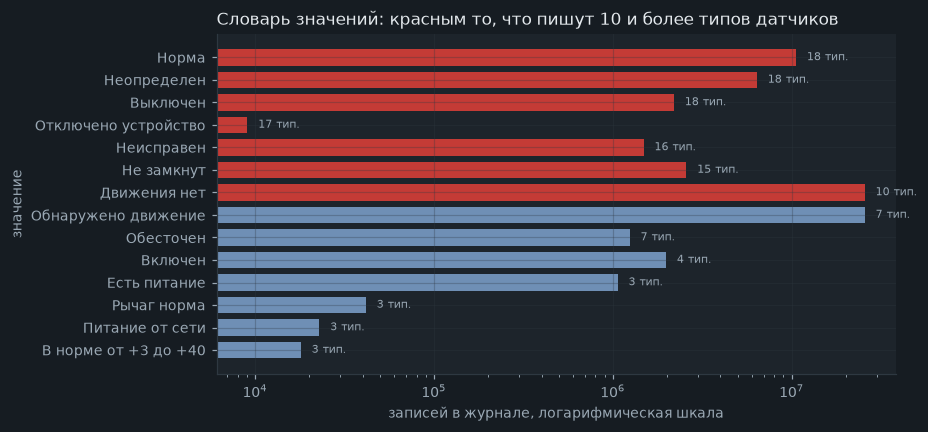

In [8]:
shared = con.sql("""
SELECT e.value AS значение,
       count(DISTINCT ch.тип_датчика) AS типов_датчиков,
       count(*) AS записей
FROM ev e JOIN ch ON ch.ид_канала_данных = e.channel_id
WHERE try_cast(e.value AS DOUBLE) IS NULL
  AND ch.тип_датчика <> 'Состояние охраны'
GROUP BY 1 ORDER BY типов_датчиков DESC, записей DESC
""").df()
display(shared.head(12))
print("всего различных нечисловых значений:", len(shared))

fig, ax = plt.subplots(figsize=(8.5, 4))
top = shared.head(14)[::-1]
colors = [RISK[3] if n >= 10 else ACCENT[0] for n in top.типов_датчиков]
ax.barh(np.arange(len(top)), top.записей, color=colors, height=0.72)
ax.set_yticks(np.arange(len(top)), top.значение)
ax.set_xscale("log")
ax.set_xlabel("записей в журнале, логарифмическая шкала")
ax.set_ylabel("значение")
ax.set_title("Словарь значений: красным то, что пишут 10 и более типов датчиков",
             loc="left", color=TEXT, fontsize=11)
for i, (_, r) in enumerate(top.iterrows()):
    ax.text(r.записей * 1.15, i, f"{r.типов_датчиков} тип.", va="center",
            fontsize=7, color=DIM)
plt.tight_layout(); plt.show()

Значения «Норма», «Неопределен» и «Выключен» пишут все девятнадцать типов.
«Движения нет» пишет одиннадцать типов, включая датчик затопления и тепловой
датчик, которым движение измерять нечем.

**Вывод для разбора.** Значение само по себе тип события не определяет. Смысл
даёт пара «тип датчика и значение». Справочник событий надо строить по паре, а
не по строке. Это же объясняет, почему в `01` мы раскладывали значения по
направлениям вручную, а не по названию датчика.

### Особый случай: «Состояние охраны»

Сорок семь каналов этого типа пишут в поле значения не состояние, а дату.

In [9]:
guard = con.sql("""
SELECT e.value AS значение, count(*) AS записей
FROM ev e JOIN ch ON ch.ид_канала_данных = e.channel_id
WHERE ch.тип_датчика = 'Состояние охраны'
GROUP BY 1 ORDER BY записей DESC LIMIT 6
""").df()
display(guard)

n_distinct = con.sql("""
SELECT count(*) FROM (SELECT DISTINCT e.value FROM ev e
JOIN ch ON ch.ид_канала_данных = e.channel_id
WHERE ch.тип_датчика = 'Состояние охраны' AND try_cast(e.value AS DOUBLE) IS NULL)
""").fetchone()[0]
print("различных значений у этого типа:", f"{n_distinct:,}".replace(",", " "))
print("из них осмысленных состояний: 2 (На охране, Снято с охраны)")

,значение,записей
0,На охране,78436
1,Снято с охраны,78421
2,01.01.1970 03:00:01,40240
3,01.01.1970 03:00:00,40225
4,Много неисправных устройств,8131
5,Устройства на объекте исправны,8128


различных значений у этого типа: 45 574
из них осмысленных состояний: 2 (На охране, Снято с охраны)


Осмысленных состояний два, остальные 45 тысяч значений это метки времени.
Больше 40 тысяч записей несут `01.01.1970 03:00:00`, то есть нулевое время Unix
со сдвигом Москвы. Это не данные, а несброшенные часы устройства.

**Вывод.** Этот тип нельзя подавать в общий разбор значений: он один раздувает
словарь с 28 строк до 45 тысяч. Его надо разбирать отдельным правилом.

## 4. Журнал значений: объём и его перекос

In [10]:
vol = con.sql("""
SELECT ch.тип_датчика AS тип,
       count(DISTINCT ch.ид_канала_данных) AS каналов,
       count(*) AS записей,
       round(count(*)::DOUBLE / count(DISTINCT ch.ид_канала_данных)) AS записей_на_канал,
       round(100.0 * avg(CASE WHEN try_cast(e.value AS DOUBLE) IS NOT NULL THEN 1 ELSE 0 END), 1)
         AS доля_числовых
FROM ev e JOIN ch ON ch.ид_канала_данных = e.channel_id
GROUP BY 1 ORDER BY записей DESC
""").df()
vol["доля_объёма"] = (100 * vol.записей / vol.записей.sum()).round(1)
display(vol)

,тип,каналов,записей,записей_на_канал,доля_числовых,доля_объёма
0,Газовый датчик,529,224012118,423463.0,99.6,73.7
1,Датчик движения,804,51473736,64022.0,0.0,16.9
2,Состояние УИР-Р,762,5684500,7460.0,0.0,1.9
3,КД Дверь,917,4986555,5438.0,0.0,1.6
4,Датчик дыма,4337,3961622,913.0,0.0,1.3
5,Состояние фазы,957,3805421,3976.0,0.0,1.3
6,Переключатель,801,3118061,3893.0,0.0,1.0
7,Состояние вентилятора,354,1987797,5615.0,0.0,0.7
8,Состояние насоса,180,1976744,10982.0,0.0,0.7
9,Датчик температуры,600,1409472,2349.0,75.5,0.5


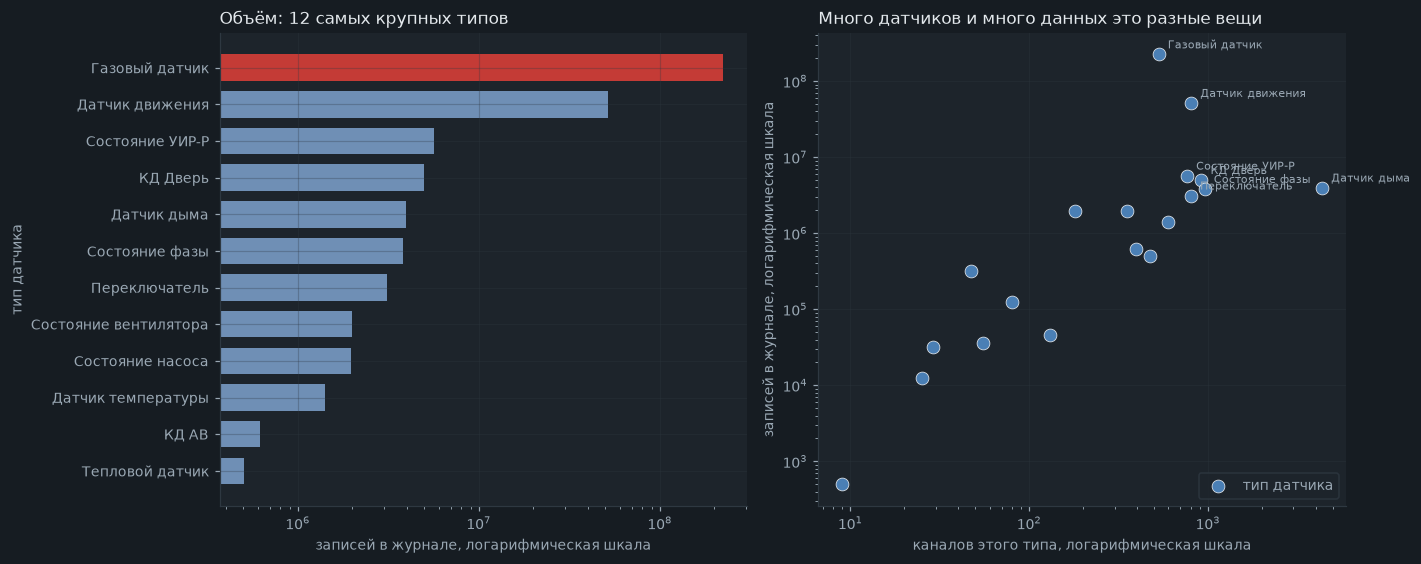

In [11]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.2))

t = vol.head(12)[::-1]
y = np.arange(len(t))
a1.barh(y, t.записей, color=[RISK[3] if v > 1e8 else ACCENT[0] for v in t.записей], height=0.72)
a1.set_yticks(y, t.тип)
a1.set_xscale("log")
a1.set_xlabel("записей в журнале, логарифмическая шкала")
a1.set_ylabel("тип датчика")
a1.set_title("Объём: 12 самых крупных типов", loc="left", color=TEXT, fontsize=11)

a2.scatter(vol.каналов, vol.записей, s=70, c=ACCENT[3], edgecolors=TEXT, linewidths=0.5,
           label="тип датчика", zorder=3)
for _, r in vol.iterrows():
    if r.записей > 3e6 or r.каналов > 800:
        a2.annotate(r.тип, (r.каналов, r.записей), fontsize=7, color=DIM,
                    xytext=(6, 4), textcoords="offset points")
a2.set_xscale("log"); a2.set_yscale("log")
a2.set_xlabel("каналов этого типа, логарифмическая шкала")
a2.set_ylabel("записей в журнале, логарифмическая шкала")
a2.set_title("Много датчиков и много данных это разные вещи", loc="left", color=TEXT, fontsize=11)
a2.legend(loc="lower right")
plt.tight_layout(); plt.show()

Перекос огромный, и он определяет всю архитектуру хранения.

**529 газовых датчиков дают 224 миллиона записей, то есть 74 % всего журнала.**
Каждый пишет в среднем 423 тысячи строк. Вторые по объёму, датчики движения,
дают ещё 17 %. Вместе два типа из девятнадцати занимают 91 % выгрузки.

При этом 4 337 дымовых датчиков, самый многочисленный тип, дают 1,3 % объёма.

Отсюда простое следствие: **грузить журнал целиком в оперативную базу
бессмысленно**. Газ и движение это телеметрия, её место в агрегатах и в архиве.
Раздел 7 показывает, во что это превращается.

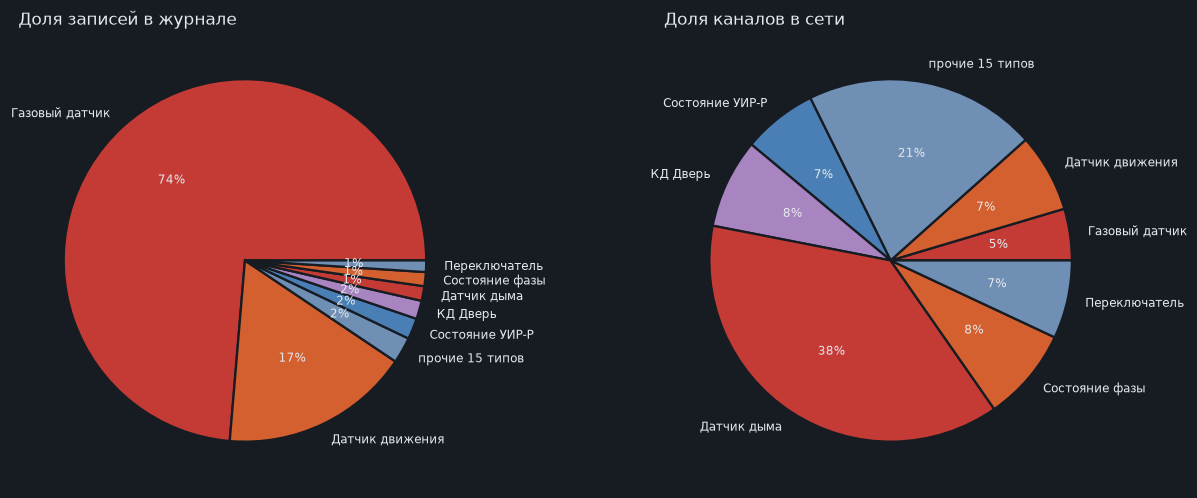

In [12]:
pie = vol.copy()
pie.loc[pie.доля_объёма < 1.0, "тип"] = "прочие 15 типов"
pie = pie.groupby("тип", as_index=False).agg(записей=("записей", "sum"),
                                             каналов=("каналов", "sum"))
pie = pie.sort_values("записей", ascending=False)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6))
cols = [RISK[3], RISK[2], ACCENT[0], ACCENT[3], ACCENT[2]][:len(pie)]
a1.pie(pie.записей, labels=pie.тип, autopct="%1.0f%%", colors=cols,
       textprops={"color": TEXT, "fontsize": 8},
       wedgeprops={"edgecolor": BG, "linewidth": 1.5})
a1.set_title("Доля записей в журнале", loc="left", color=TEXT, fontsize=11)
a2.pie(pie.каналов, labels=pie.тип, autopct="%1.0f%%", colors=cols,
       textprops={"color": TEXT, "fontsize": 8},
       wedgeprops={"edgecolor": BG, "linewidth": 1.5})
a2.set_title("Доля каналов в сети", loc="left", color=TEXT, fontsize=11)
plt.tight_layout(); plt.show()

## 5. Такт опроса и природа значений

Каналы делятся на два класса, и работать с ними надо по-разному.

**Числовые** отдают величину: газ, температура, заряд ИБП. Для них осмысленны
среднее, тренд и производная.

**Дискретные** отдают состояние: замкнут, движение, включён. Для них осмысленны
частота смены состояния и длительность пребывания в нём.

In [13]:
cadence = con.sql("""
WITH s AS (
  SELECT ch.тип_датчика AS тип, e.channel_id AS cid,
         date_diff('second', (e.d + e.t),
                   lead(e.d + e.t) OVER (PARTITION BY e.channel_id ORDER BY e.d, e.t)) AS g
  FROM ev e JOIN ch ON ch.ид_канала_данных = e.channel_id
  WHERE e.d BETWEEN DATE '2024-03-01' AND DATE '2024-03-08'
)
SELECT тип, count(DISTINCT cid) AS каналов,
       median(g) AS медиана_сек, quantile_cont(g, 0.9) AS p90_сек
FROM s WHERE g IS NOT NULL AND g > 0 GROUP BY 1 ORDER BY медиана_сек
""").df()
cadence = cadence.merge(vol[["тип", "доля_числовых"]], on="тип", how="left")
display(cadence)

,тип,каналов,медиана_сек,p90_сек,доля_числовых
0,Датчик движения,371,4.0,64.0,0.0
1,Стекло,6,7.0,77695.5,0.0
2,Газовый датчик,242,9.0,155.0,99.6
3,Состояние УИР-Р,67,21.0,7936.0,0.0
4,КД Дверь,475,24.0,2738.9,0.0
5,ИБП,21,34.0,9193.9,3.7
6,Ручной извещатель,4,39.0,1899.7,0.0
7,Датчик дыма,76,134.0,7543.0,0.0
8,Состояние насоса,88,171.0,11145.8,0.0
9,КД АВ,116,175.0,8676.0,0.0


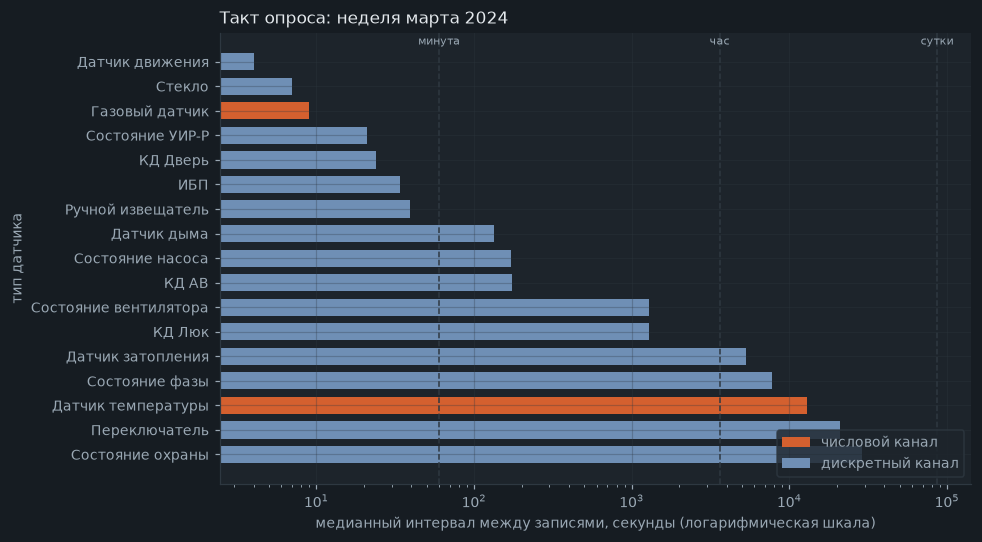

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
d = cadence.sort_values("медиана_сек")
y = np.arange(len(d))[::-1]
num = d.доля_числовых > 50
ax.barh(y[num.to_numpy()], d.медиана_сек[num], color=RISK[2], height=0.7, label="числовой канал")
ax.barh(y[~num.to_numpy()], d.медиана_сек[~num], color=ACCENT[0], height=0.7, label="дискретный канал")
ax.set_yticks(y, d.тип)
ax.set_xscale("log")
ax.set_xlabel("медианный интервал между записями, секунды (логарифмическая шкала)")
ax.set_ylabel("тип датчика")
ax.set_title("Такт опроса: неделя марта 2024", loc="left", color=TEXT, fontsize=11)
for x, lbl in [(60, "минута"), (3600, "час"), (86400, "сутки")]:
    ax.axvline(x, color=LINE, ls="--", lw=1)
    ax.text(x, len(d) - 0.3, lbl, color=DIM, fontsize=7, ha="center")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

Разброс в пять порядков: датчик движения пишет каждые четыре секунды,
переключатель раз в шесть часов.

**Это не регулярный опрос, а поток изменений.** Запись появляется, когда
значение изменилось, а не по расписанию. Отсюда важное следствие для признаков:
отсутствие записи не означает отсутствие данных, оно означает «всё по-прежнему».
Считая частоту событий, делить надо на календарные дни, а не на дни с записями.

### Числовые каналы: где кончаются данные и начинается мусор

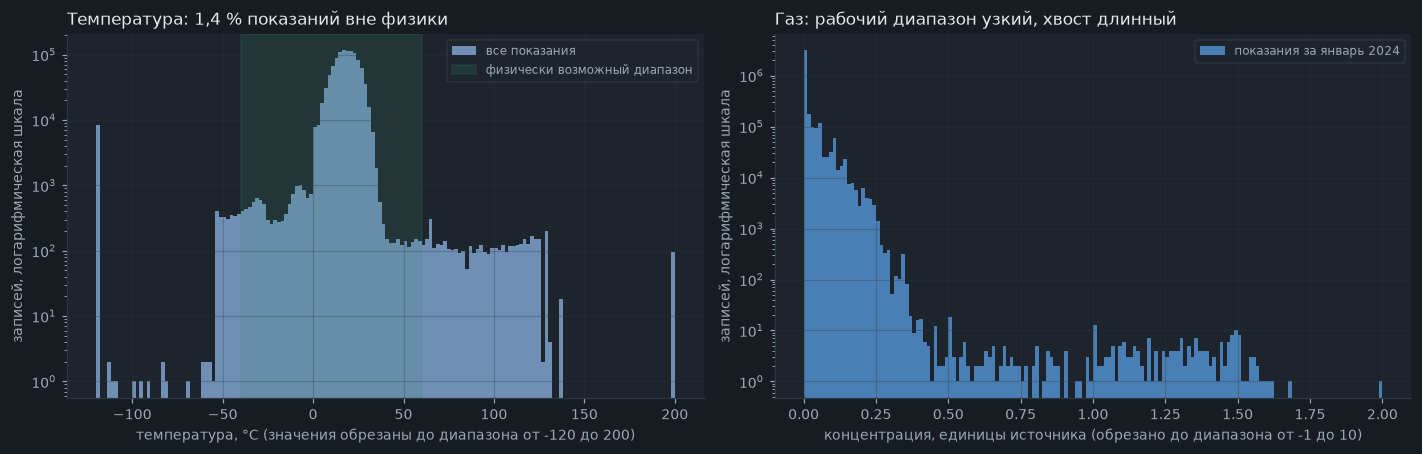

температура: минимум -3276, максимум 999, медиана 18, доля в диапазоне от -40 до 60: 98.58 %


In [15]:
temp = con.sql("""
SELECT try_cast(e.value AS DOUBLE) AS v
FROM ev e JOIN ch ON ch.ид_канала_данных = e.channel_id
WHERE ch.тип_датчика = 'Датчик температуры' AND try_cast(e.value AS DOUBLE) IS NOT NULL
""").df().v.to_numpy()

gas = con.sql("""
SELECT try_cast(e.value AS DOUBLE) AS v
FROM ev e JOIN ch ON ch.ид_канала_данных = e.channel_id
WHERE ch.тип_датчика = 'Газовый датчик' AND try_cast(e.value AS DOUBLE) IS NOT NULL
  AND e.d BETWEEN DATE '2024-01-01' AND DATE '2024-02-01'
""").df().v.to_numpy()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))

a1.hist(np.clip(temp, -120, 200), bins=160, color=ACCENT[0], label="все показания")
a1.axvspan(-40, 60, color=RISK[0], alpha=0.18, label="физически возможный диапазон")
a1.set_yscale("log")
a1.set_xlabel("температура, °C (значения обрезаны до диапазона от -120 до 200)")
a1.set_ylabel("записей, логарифмическая шкала")
a1.set_title("Температура: 1,4 % показаний вне физики", loc="left", color=TEXT, fontsize=11)
a1.legend(loc="upper right", fontsize=8)

a2.hist(np.clip(gas, -1, 10), bins=160, color=ACCENT[3], label="показания за январь 2024")
a2.set_yscale("log")
a2.set_xlabel("концентрация, единицы источника (обрезано до диапазона от -1 до 10)")
a2.set_ylabel("записей, логарифмическая шкала")
a2.set_title("Газ: рабочий диапазон узкий, хвост длинный", loc="left", color=TEXT, fontsize=11)
a2.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

print(f"температура: минимум {temp.min():.0f}, максимум {temp.max():.0f}, "
      f"медиана {np.median(temp):.0f}, доля в диапазоне от -40 до 60: "
      f"{100*np.mean((temp >= -40) & (temp <= 60)):.2f} %")

Крайние значения выдают себя происхождением. Минимум температуры равен -3276,
это `-32767 / 10`. Максимум газа равен 327.68, это `32768 / 100`. Оба числа
получены из переполненного шестнадцатибитного регистра, то есть это не холод и
не загазованность, а отказ измерения.

Заказчик на QA-сессии подтвердил: производители ставят такие числа вместо
признака ошибки, и он сам на них не смотрит.

**Что с ними делать.** Из расчёта величины исключать, но сохранять как отдельный
признак «датчик отдал недопустимое число». Это бесплатный сигнал неисправности,
и выбрасывать его молча жалко.

## 6. На что смотреть при ручном анализе

Собрано по тому, на чём мы уже спотыкались.

In [16]:
checks = pd.DataFrame([
    ("Флаг важнее текста",
     "«Обнаружен дым» встречается 195 955 раз, тревожных из них 42 433",
     "фильтровать по тревожное, текст брать только для типа события"),
    ("Значение не задаёт тип события",
     "«Норма» и «Неопределен» пишут все 19 типов датчиков",
     "смысл даёт пара «тип датчика и значение»"),
    ("Строчные инструменты врут",
     "значения содержат запятые и переносы, wc -l даёт 11 494 канала вместо 11 485",
     "читать CSV разборщиком, а не построчно"),
    ("Повторный заголовок",
     "ext-journal-2025.csv склеен, заголовок на строке 26 140 585",
     "фильтр TRY_CAST(ид_события AS BIGINT) IS NOT NULL"),
    ("Артефакт миграции",
     "объект 5343 дал 1 036 606 записей «Неисправен» за 2020 и 2021",
     "исключать объект за два года, а не годы целиком"),
    ("Переполнение регистра",
     "температура -3276 это -32767/10, газ 327.68 это 32768/100",
     "в величину не брать, оставить признаком отказа"),
    ("Несброшенные часы",
     "«Состояние охраны» пишет 01.01.1970 в 40 тысячах записей",
     "разбирать этот тип отдельным правилом"),
    ("Нет записи не значит нет данных",
     "журнал пишет изменения, а не опрос по расписанию",
     "частоту делить на календарные дни, а не на дни с записями"),
    ("Каналы-сироты",
     "1 142 канала журнала отсутствуют в справочнике, 6 % всех тревог",
     "исключать из обучения и показывать счётчиком"),
    ("Порядок строк не задан",
     "параллельный join DuckDB отдаёт строки в произвольном порядке",
     "ORDER BY в любом запросе, результат которого идёт в модель"),
    ("Тег инженерной системы избыточен",
     "остаток протокола MQ, оставлен при обезличивании по ошибке",
     "связь брать через ид_объект"),
    ("Сеть неоднородна",
     "в комплексе Мю 1 487 каналов, в Сигме 75",
     "не усреднять по сети без взвешивания"),
], columns=["ловушка", "в чём она", "что делать"])
display(checks.style.hide(axis="index"))

ловушка,в чём она,что делать
Флаг важнее текста,"«Обнаружен дым» встречается 195 955 раз, тревожных из них 42 433","фильтровать по тревожное, текст брать только для типа события"
Значение не задаёт тип события,«Норма» и «Неопределен» пишут все 19 типов датчиков,смысл даёт пара «тип датчика и значение»
Строчные инструменты врут,"значения содержат запятые и переносы, wc -l даёт 11 494 канала вместо 11 485","читать CSV разборщиком, а не построчно"
Повторный заголовок,"ext-journal-2025.csv склеен, заголовок на строке 26 140 585",фильтр TRY_CAST(ид_события AS BIGINT) IS NOT NULL
Артефакт миграции,объект 5343 дал 1 036 606 записей «Неисправен» за 2020 и 2021,"исключать объект за два года, а не годы целиком"
Переполнение регистра,"температура -3276 это -32767/10, газ 327.68 это 32768/100","в величину не брать, оставить признаком отказа"
Несброшенные часы,«Состояние охраны» пишет 01.01.1970 в 40 тысячах записей,разбирать этот тип отдельным правилом
Нет записи не значит нет данных,"журнал пишет изменения, а не опрос по расписанию","частоту делить на календарные дни, а не на дни с записями"
Каналы-сироты,"1 142 канала журнала отсутствуют в справочнике, 6 % всех тревог",исключать из обучения и показывать счётчиком
Порядок строк не задан,параллельный join DuckDB отдаёт строки в произвольном порядке,"ORDER BY в любом запросе, результат которого идёт в модель"


### Суточный и недельный ритм

Последнее, на что стоит посмотреть перед тем, как строить признаки: когда
тревоги приходят. Если ритм есть, время суток и день недели обязаны попасть в
модель.

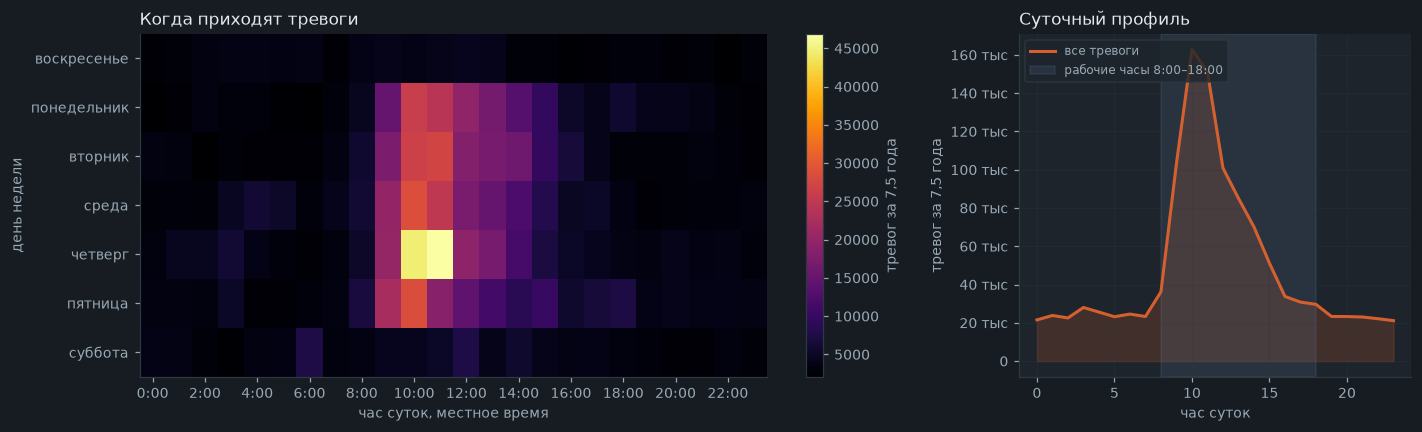

доля тревог в рабочие часы 8:00–18:00: 71.1% (равномерно было бы 41,7 %)


In [17]:
rhythm = con.sql("""
SELECT hour(e.t) AS час, dayofweek(e.d) AS дн, count(*) AS тревог
FROM ev e JOIN ch ON ch.ид_канала_данных = e.channel_id
WHERE e.alarm AND NOT (ch.ид_объект = 5343 AND year(e.d) IN (2020, 2021))
GROUP BY 1, 2
""").df()
grid = rhythm.pivot(index="дн", columns="час", values="тревог").fillna(0)
days = ["воскресенье", "понедельник", "вторник", "среда", "четверг", "пятница", "суббота"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4), width_ratios=[2, 1])
im = a1.imshow(grid.to_numpy(), aspect="auto", cmap="inferno")
a1.set_yticks(range(7), [days[i] for i in grid.index])
a1.set_xticks(range(0, 24, 2), [f"{h}:00" for h in range(0, 24, 2)])
a1.set_xlabel("час суток, местное время")
a1.set_ylabel("день недели")
a1.set_title("Когда приходят тревоги", loc="left", color=TEXT, fontsize=11)
a1.grid(False)
fig.colorbar(im, ax=a1, label="тревог за 7,5 года")

per_hour = grid.sum(axis=0)
a2.plot(per_hour.index, per_hour.to_numpy(), color=RISK[2], lw=2, label="все тревоги")
a2.fill_between(per_hour.index, per_hour.to_numpy(), color=RISK[2], alpha=0.2)
a2.axvspan(8, 18, color=ACCENT[0], alpha=0.15, label="рабочие часы 8:00–18:00")
a2.set_xlabel("час суток")
a2.set_ylabel("тревог за 7,5 года")
a2.yaxis.set_major_formatter(SI)
a2.set_title("Суточный профиль", loc="left", color=TEXT, fontsize=11)
a2.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

work = per_hour[8:18].sum() / per_hour.sum()
print(f"доля тревог в рабочие часы 8:00–18:00: {work:.1%} (равномерно было бы 41,7 %)")

Ритм есть, и он выраженный. Значит час суток и день недели входят в признаки.
Заказчик добавил к этому календарь: длинные праздники и особые даты вроде 9 мая
поднимают риск несанкционированного доступа.

## 7. Как это хранить, чтобы модель можно было дообучать

Раздел отвечает на вопрос, вынесенный в задачу: какая схема данных нужна, чтобы
сервис мог дообучаться при появлении новых данных.

### Что диктуют цифры

1. 313 млн строк, из них 91 % это телеметрия газа и движения.
2. Тревог всего 2,47 млн, то есть 0,79 %.
3. Данные приходят потоком изменений, дописываются и не правятся задним числом.
4. Направлений прогнозирования четыре, и признаки у них разные.

### Три контура вместо одной таблицы

Держать всё в одной таблице PostgreSQL нельзя: оперативные запросы диспетчера
пойдут по тем же страницам, что и переобучение модели.

контур,где лежит,кто читает,как часто
Архив,"parquet на диске, партиции по месяцу","переобучение, разбор инцидентов","редко, пакетно"
Оперативный,"PostgreSQL 12+, партиции по месяцу","прогноз, карточка прогноза, журнал",постоянно
Витрина,"PostgreSQL, обычные таблицы",обучение и метрики,по расписанию


сырьё:                            313 546 016
тревоги:                          2 467 812
смены состояния:                  86 340 358
пары «канал и час»:               15 854 375

вариант A, только смены:          86 340 358 сжатие в 3.6 раза
вариант B, тревоги + часовые:     18 322 187 сжатие в 17 раз


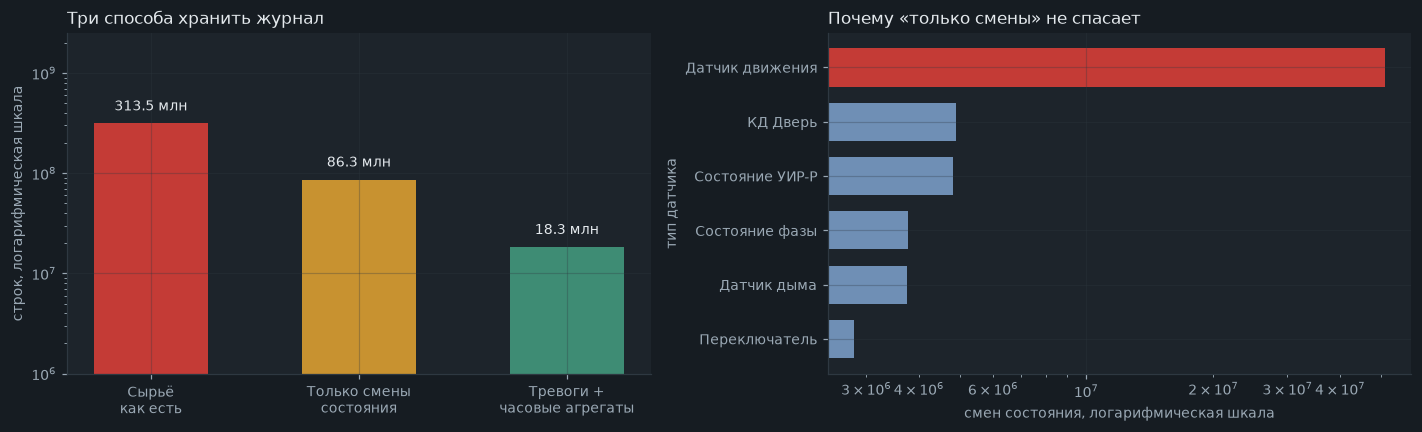

датчик движения даёт 59% всех смен состояния
витрина: 1 420 920 строк на направление (3947 единиц x 4 снимка в сутки x 90 дней)


In [18]:
layers = pd.DataFrame([
    ("Архив", "parquet на диске, партиции по месяцу",
     "переобучение, разбор инцидентов", "редко, пакетно"),
    ("Оперативный", "PostgreSQL 12+, партиции по месяцу",
     "прогноз, карточка прогноза, журнал", "постоянно"),
    ("Витрина", "PostgreSQL, обычные таблицы",
     "обучение и метрики", "по расписанию"),
], columns=["контур", "где лежит", "кто читает", "как часто"])
display(layers.style.hide(axis="index"))

# Считаем, а не прикидываем. Проверяем три способа ужать журнал.
sizing = con.sql("""
SELECT
  (SELECT count(*) FROM ev)                                             AS raw_rows,
  (SELECT count(*) FROM ev WHERE alarm)                                 AS alarms,
  (SELECT count(*) FROM (
     SELECT channel_id, value,
            lag(value) OVER (PARTITION BY channel_id ORDER BY d, t) AS prev
     FROM ev WHERE try_cast(value AS DOUBLE) IS NULL)
   WHERE prev IS NULL OR value <> prev)                                 AS state_changes,
  (SELECT count(*) FROM (
     SELECT DISTINCT channel_id, date_trunc('hour', d + t) AS h FROM ev)) AS channel_hours
""").df().iloc[0]

raw = int(sizing.raw_rows)
alarms = int(sizing.alarms)
changes = int(sizing.state_changes)
hours = int(sizing.channel_hours)

fmt = lambda n: f"{n:,}".replace(",", " ")
print("сырьё:                           ", fmt(raw))
print("тревоги:                         ", fmt(alarms))
print("смены состояния:                 ", fmt(changes))
print("пары «канал и час»:              ", fmt(hours))
print()
print("вариант A, только смены:         ", fmt(changes), f"сжатие в {raw/changes:.1f} раза")
print("вариант B, тревоги + часовые:    ", fmt(alarms + hours),
      f"сжатие в {raw/(alarms+hours):.0f} раз")

# Витрина: единиц прогноза x снимков в сутки x дней хранения снимков.
UNITS, SNAPSHOTS_PER_DAY, KEEP_DAYS = 3947, 4, 90
mart = UNITS * SNAPSHOTS_PER_DAY * KEEP_DAYS

NL = chr(10)   # перенос строки в подписи столбца

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))

opts = ["Сырьё" + NL + "как есть", "Только смены" + NL + "состояния",
        "Тревоги +" + NL + "часовые агрегаты"]
vals = [raw, changes, alarms + hours]
bars = a1.bar(opts, vals, color=[RISK[3], RISK[1], RISK[0]], width=0.55)
a1.set_yscale("log")
a1.set_ylabel("строк, логарифмическая шкала")
a1.set_title("Три способа хранить журнал", loc="left", color=TEXT, fontsize=11)
for b, v in zip(bars, vals):
    a1.text(b.get_x() + b.get_width() / 2, v * 1.35, f"{v/1e6:.1f} млн",
            ha="center", color=TEXT, fontsize=9)
a1.set_ylim(1e6, raw * 8)

by_type = con.sql("""
SELECT тип_датчика AS t, count(*) AS n FROM (
  SELECT ch.тип_датчика, e.value AS v,
         lag(e.value) OVER (PARTITION BY e.channel_id ORDER BY e.d, e.t) AS p
  FROM ev e JOIN ch ON ch.ид_канала_данных = e.channel_id
  WHERE try_cast(e.value AS DOUBLE) IS NULL)
WHERE p IS NULL OR v <> p GROUP BY 1 ORDER BY n DESC LIMIT 6
""").df()
y = np.arange(len(by_type))[::-1]
a2.barh(y, by_type.n, height=0.7,
        color=[RISK[3] if v > 2e7 else ACCENT[0] for v in by_type.n])
a2.set_yticks(y, by_type.t)
a2.set_xscale("log")
a2.set_xlabel("смен состояния, логарифмическая шкала")
a2.set_ylabel("тип датчика")
a2.set_title("Почему «только смены» не спасает", loc="left", color=TEXT, fontsize=11)
plt.tight_layout(); plt.show()

print(f"датчик движения даёт {by_type.n.iloc[0]/changes:.0%} всех смен состояния")
print("витрина:", fmt(mart), "строк на направление",
      f"({UNITS} единиц x {SNAPSHOTS_PER_DAY} снимка в сутки x {KEEP_DAYS} дней)")

Цифры выше отвечают на главный вопрос схемы, и ответ оказался не тем, которого
мы ждали.

**Хранить только смены состояния почти не помогает.** Кажется очевидным: зачем
писать «движения нет» второй раз подряд. Но датчик движения чередует два
состояния на каждой записи, и он один даёт 59 % всех смен. Сжатие выходит меньше
чем в четыре раза, а сложность разбора растёт.

**Работает почасовая свёртка.** Тревоги храним поштучно, всё остальное сворачиваем
в час: сколько записей, сколько смен состояния, сколько времени канал провёл в
тревоге, минимум, максимум и среднее у числовых. Получается около 18 млн строк
вместо 313 млн, то есть в 17 раз меньше.

Час выбран не случайно. Горизонт прогноза по ТЗ §9 не меньше 24 часов, и
разрешение в час его не портит. Хранить посекундную телеметрию ради суточного
прогноза незачем.

Полное разрешение остаётся в архиве. Если через год понадобится признак с
минутным разрешением, parquet никуда не денется.

### Таблицы оперативного контура

```
справочники, меняются редко
  facility_tree    район, комплекс, объект             95 строк
  facility         единица прогноза: объект и пикет    3 947 строк
  sensor           канал датчика                       11 485 строк
  event_type       тип датчика + значение -> смысл     ~120 строк

факты, только дозапись
  alarm_event      тревоги поштучно, партиции по месяцу  2,5 млн
  channel_hourly   свёртка канала в час                 15,9 млн
  ingest_batch     что и когда загружено                строка на пакет
```

Колонки `channel_hourly`: канал, час, число записей, число смен состояния,
секунд в тревожном состоянии, минимум, максимум, среднее и число недопустимых
значений у числовых каналов. Одна таблица закрывает и газ с его девятисекундным
тактом, и переключатель с его шестью часами.

Таблица `event_type` заслуживает отдельного слова. Она хранит тройку «тип
датчика, значение, направление». Именно она, а не `if` в коде, отвечает на
вопрос, к какому направлению относится событие. Новое значение от нового
производителя тогда добавляется строкой, а не релизом.

### Разделение по направлениям

Задача просила разделить таблицы по направлениям анализа. Разделять надо не
везде, и вот граница.

**Не разделять события и свёртки.** Одна тревога кормит несколько направлений
сразу: «Неисправен» на дымовом датчике это и отказ датчика, и ослепший пожарный
контур. Физически разрезав таблицу, мы получим дубли и рассинхрон, а новое
направление потребует миграции. К тому же словарь значений общий на все типы
датчиков, значит и разрез по направлению не выйдет чистым.

**Разделять признаки и метки.** Здесь схемы действительно разные: подтоплению
нужны мигание насоса и осадки, доступу нужны последовательность сработок и
календарь праздников. Общая широкая таблица на все направления будет наполовину
пустой.

```
feature_snapshot_<направление>
    facility_id, as_of, features JSONB, feature_set_version

label_<направление>
    facility_id, as_of, horizon_hours, y, finalized_at
```

In [19]:
scheme = pd.DataFrame([
    ("facility_tree", "общая", "дерево объектов", "меняется редко"),
    ("facility", "общая", "единица прогноза", "меняется редко"),
    ("sensor", "общая", "каналы", "меняется редко"),
    ("event_type", "общая", "значение -> направление", "растёт строками"),
    ("alarm_event", "общая", "тревоги поштучно", "только дозапись"),
    ("channel_hourly", "общая", "свёртка канала в час", "только дозапись"),
    ("ingest_batch", "общая", "что и когда загружено", "только дозапись"),
    ("feature_snapshot_*", "по направлению", "признаки на момент", "пересчёт по расписанию"),
    ("label_*", "по направлению", "метка с горизонтом", "дозапись по мере созревания"),
    ("model_metric", "по направлению", "замеры качества", "дозапись"),
], columns=["таблица", "разделение", "что хранит", "как меняется"])
display(scheme.style.hide(axis="index"))

таблица,разделение,что хранит,как меняется
facility_tree,общая,дерево объектов,меняется редко
facility,общая,единица прогноза,меняется редко
sensor,общая,каналы,меняется редко
event_type,общая,значение -> направление,растёт строками
alarm_event,общая,тревоги поштучно,только дозапись
channel_hourly,общая,свёртка канала в час,только дозапись
ingest_batch,общая,что и когда загружено,только дозапись
feature_snapshot_*,по направлению,признаки на момент,пересчёт по расписанию
label_*,по направлению,метка с горизонтом,дозапись по мере созревания
model_metric,по направлению,замеры качества,дозапись


### Что делает дообучение возможным

Четыре правила. Без них дообучение превращается в переобучение с нуля, а метрики
перестают быть сравнимыми.

**1. Только дозапись.** Событие, попавшее в базу, не правится и не удаляется.
Тогда выборка, на которой училась модель версии N, воспроизводима через год.

**2. Водяной знак загрузки.** Таблица `ingest_batch` хранит, какой файл или
какое окно потока загружено и когда. Дообучение берёт данные строго после
водяного знака прошлого прогона, и одна и та же строка не попадает в обучение
дважды.

**3. Снимок признаков неизменяем.** Строка `feature_snapshot` считается один раз
на момент `as_of` и больше не трогается. Это главная защита от утечки по
времени: пересчитанный сегодня признак «за прошлый март» неизбежно увидел бы
будущее.

**4. Метка созревает.** Метка для момента `as_of` становится окончательной
только когда `as_of + horizon_hours` уже в прошлом. До этого строка есть, но
`finalized_at` пуст, и в обучение она не идёт. Иначе модель будет учиться на
событиях, которые ещё не успели произойти.

### Цикл дообучения

```
новые данные -> ingest_batch -> alarm_event + channel_hourly
                                            |
                            feature_snapshot_<направление> на новые as_of
                                            |
                            label_<направление>, где горизонт уже закрылся
                                            |
                    обучение на окне [начало ... T-horizon], проверка на [T-horizon ... T]
                                            |
                              MLflow: версия модели + границы окна + версия признаков
                                            |
                          model_metric: Precision и Recall с датой замера
```

Разбиение при обучении только по времени. Случайное разбиение на потоке событий
даёт утечку и завышенные метрики, что вскроется на защите.

Версия набора признаков (`feature_set_version`) хранится рядом со снимком.
Поменяли формулу признака, подняли версию, и старые снимки не смешиваются с
новыми молча.

### Чего в схеме нет намеренно

Таблиц `repair`, `permit`, `inspection` и `fault_log` нет. Заказчик на QA-сессии
сказал прямо: историю ремонтов в компании не ведут вовсе, реестр оборудования
сузили до датчиков. Источника они не получат никогда, и держать пустые таблицы
ради красоты схемы не нужно.

Таблица `weather_hourly` остаётся: открытые API метеослужб являются штатным
источником по ТЗ §13, и сценарий подтопления на них опирается.

## Итог

- Выгрузка это один поток изменений на 313 млн строк плюс два справочника.
- 91 % объёма дают два типа датчиков из девятнадцати. Газ и движение это
  телеметрия, остальное события.
- Словарь значений мал, 28 строк, но общий на все типы. Смысл даёт пара «тип
  датчика и значение», а не значение само по себе.
- Числовые каналы несут мусор от переполнения регистров. Его надо не
  выбрасывать, а превращать в признак отказа.
- Хранить надо в трёх контурах. Почасовая свёртка ужимает журнал в 17 раз и
  горизонту в 24 часа не мешает. Хранение только смен состояния не помогает:
  датчик движения чередует состояния на каждой записи.
- Разделять по направлениям надо признаки и метки, но не события.
- Дообучение держится на четырёх правилах: только дозапись, водяной знак,
  неизменяемый снимок признаков и созревающая метка.

Дальше: `01-eda-clustering.ipynb` строит признаки и ищет группы каналов.